# VGG-based Face Recognition (Improved)
## FYP: Comparing VGG vs Autoencoder for Face Recognition on LFW Dataset

This notebook implements an improved VGG classifier for face recognition with proper data augmentation, regularization, and comprehensive evaluation metrics.

## Section 0: Imports

In [1]:
import os, glob, random, json, time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, backend as K
from collections import Counter
import matplotlib.pyplot as plt
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-03-21 15:59:36.401831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774108776.655978      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774108776.718723      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774108777.290311      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774108777.290351      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774108777.290354      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Section 1: Configuration

In [2]:
DATA_DIR = "/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled"
OUT_DIR = "/kaggle/working/vgg_classifier"
os.makedirs(OUT_DIR, exist_ok=True)
IMG_SIZE = 128
BATCH_SIZE = 64
SEED = 42
MIN_IMAGES_PER_ID = 10
TOP_K = 200
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
EPOCHS = 60
LR = 1e-3
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("Config OK")

Config OK


## Section 2: Data Pipeline

Filter identities by minimum images, select top-k, create 70/15/15 split with augmentation on training set.

In [3]:
# Step 1: Collect identities and filter
people = []
for person in sorted(os.listdir(DATA_DIR)):
    pdir = os.path.join(DATA_DIR, person)
    if not os.path.isdir(pdir):
        continue
    imgs = glob.glob(os.path.join(pdir, "*.jpg")) + glob.glob(os.path.join(pdir, "*.png"))
    if len(imgs) >= MIN_IMAGES_PER_ID:
        people.append((person, len(imgs)))

# Sort by count descending and take top-k
people.sort(key=lambda x: x[1], reverse=True)
people = people[:TOP_K]
NUM_CLASSES = len(people)
print(f"Selected {NUM_CLASSES} identities")
print(f"Image counts: min={people[-1][1]}, max={people[0][1]}, mean={np.mean([c for _, c in people]):.1f}")

Selected 158 identities
Image counts: min=10, max=530, mean=27.4


In [4]:
# Step 2: Build dataset lists
train_imgs = []
train_labels = []
val_imgs = []
val_labels = []
test_imgs = []
test_labels = []

for person_idx, (person, _) in enumerate(people):
    pdir = os.path.join(DATA_DIR, person)
    imgs = sorted(glob.glob(os.path.join(pdir, "*.jpg")) + glob.glob(os.path.join(pdir, "*.png")))
    random.shuffle(imgs)
    n = len(imgs)
    n_train = int(TRAIN_RATIO * n)
    n_val = int(VAL_RATIO * n)
    n_train = max(1, n_train)
    n_val = max(1, n_val)
    if n_train + n_val >= n:
        n_train = n - n_val - 1
        n_train = max(1, n_train)
    n_test = n - n_train - n_val
    if n_test < 1:
        n_train -= 1
        n_test = 1
    tr = imgs[:n_train]
    va = imgs[n_train:n_train + n_val]
    te = imgs[n_train + n_val:]
    train_imgs.extend(tr)
    train_labels.extend([person_idx] * len(tr))
    val_imgs.extend(va)
    val_labels.extend([person_idx] * len(va))
    test_imgs.extend(te)
    test_labels.extend([person_idx] * len(te))

print(f"Train: {len(train_imgs)}, Val: {len(val_imgs)}, Test: {len(test_imgs)}")

Train: 2959, Val: 566, Test: 799


In [5]:
# Step 3: Load and preprocess images
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 127.5 - 1.0  # Normalize to [-1, 1]
    return img, label

def augment_image(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    return img, y

# Create datasets
train_ds = tf.data.Dataset.from_tensor_slices((train_imgs, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=len(train_imgs))
train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_imgs, val_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_imgs, test_labels))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets created successfully")

I0000 00:00:1774108878.555381      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774108878.557884      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets created successfully


## Section 3: Model Architecture (Improved VGG)

In [6]:
def vgg_block(x, filters, convs, name_prefix):
    for i in range(convs):
        x = layers.Conv2D(filters, (3,3), padding="same",
                          kernel_initializer="he_normal",
                          kernel_regularizer=keras.regularizers.l2(1e-4),
                          name=f"{name_prefix}_conv{i+1}")(x)
        x = layers.BatchNormalization(name=f"{name_prefix}_bn{i+1}")(x)
        x = layers.Activation("relu", name=f"{name_prefix}_relu{i+1}")(x)
    x = layers.MaxPooling2D((2,2), strides=2, name=f"{name_prefix}_pool")(x)
    return x

def build_vgg_classifier(num_classes):
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    x = vgg_block(inp, 64, 2, "b1")    # 128->64
    x = vgg_block(x, 128, 2, "b2")     # 64->32
    x = vgg_block(x, 256, 3, "b3")     # 32->16
    x = vgg_block(x, 512, 3, "b4")     # 16->8
    x = vgg_block(x, 512, 3, "b5")     # 8->4
    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.Dense(512, kernel_initializer="he_normal", name="fc1")(x)
    x = layers.BatchNormalization(name="fc1_bn")(x)
    x = layers.Activation("relu", name="fc1_relu")(x)
    x = layers.Dropout(0.5, name="drop1")(x)
    x = layers.Dense(256, kernel_initializer="he_normal", name="fc2")(x)
    x = layers.BatchNormalization(name="fc2_bn")(x)
    x = layers.Activation("relu", name="fc2_relu")(x)
    x = layers.Dropout(0.3, name="drop2")(x)
    out = layers.Dense(num_classes, activation="softmax", name="softmax")(x)
    return keras.Model(inp, out, name="VGG_Classifier")

model = build_vgg_classifier(NUM_CLASSES)
model.compile(
    optimizer=keras.optimizers.Adam(LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "VGG_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv1 (Conv2D)               │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn1 (BatchNormalization)     │ (None, 128, 128, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_relu1 (Activation)           │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_conv2 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_bn2 (BatchNormalization)     │ (None, 128, 128, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_relu2 (Activation)           │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b1_pool (MaxPooling2D)          │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv1 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn1 (BatchNormalization)     │ (None, 64, 64, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_relu1 (Activation)           │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_conv2 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_bn2 (BatchNormalization)     │ (None, 64, 64, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_relu2 (Activation)           │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b2_pool (MaxPooling2D)          │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv1 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn1 (BatchNormalization)     │ (None, 32, 32, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_relu1 (Activation)           │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv2 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn2 (BatchNormalization)     │ (None, 32, 32, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_relu2 (Activation)           │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_conv3 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_bn3 (BatchNormalization)     │ (None, 32, 32, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_relu3 (Activation)           │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ b3_pool (MaxPooling2D)          │ (None, 16, 16, 256)    │             

 Total params: 15,169,246 (57.87 MB)

 Trainable params: 15,159,262 (57.83 MB)

 Non-trainable params: 9,984 (39.00 KB)

## Section 3b: Model Size Analysis

In [7]:
def count_params(model):
    trainable = sum([K.count_params(w) for w in model.trainable_weights])
    non_trainable = sum([K.count_params(w) for w in model.non_trainable_weights])
    total = trainable + non_trainable
    size_mb = total * 4 / (1024 * 1024)  # float32
    return trainable, non_trainable, total, size_mb

trainable, non_trainable, total, size_mb = count_params(model)
print(f"Trainable params: {trainable:,}")
print(f"Non-trainable params: {non_trainable:,}")
print(f"Total params: {total:,}")
print(f"Model size: {size_mb:.2f} MB")

Trainable params: 15,159,262
Non-trainable params: 9,984
Total params: 15,169,246
Model size: 57.87 MB


## Section 4: Training

In [8]:
best_model_path = os.path.join(OUT_DIR, "best_model.keras")
history_path = os.path.join(OUT_DIR, "history.json")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        best_model_path,
        monitor="val_accuracy",
        save_best_only=True,
        mode="max"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=10,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-7
    )
]

print("Starting training...")
start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Save history
history_dict = {
    'loss': [float(x) for x in history.history['loss']],
    'accuracy': [float(x) for x in history.history['accuracy']],
    'val_loss': [float(x) for x in history.history['val_loss']],
    'val_accuracy': [float(x) for x in history.history['val_accuracy']]
}
with open(history_path, 'w') as f:
    json.dump(history_dict, f)
print(f"History saved to {history_path}")

Starting training...
Epoch 1/60


I0000 00:00:1774108897.571913     125 service.cc:152] XLA service 0x7d98b0002300 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774108897.571947     125 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774108897.571951     125 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774108899.398850     125 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-21 16:01:53.799055: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 16:01:54.016669: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 16:01:55.376864: E external/local_xl

46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.0410 - loss: 6.0718

2026-03-21 16:02:34.878253: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 16:02:35.062881: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 16:02:35.553399: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 16:02:35.716971: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-21 16:02:36.664444: E external/local_xla/xla/stream_

47/47 ━━━━━━━━━━━━━━━━━━━━ 96s 971ms/step - accuracy: 0.0425 - loss: 6.0643 - val_accuracy: 0.0071 - val_loss: 173.7946 - learning_rate: 0.0010
Epoch 2/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 379ms/step - accuracy: 0.1117 - loss: 5.5571 - val_accuracy: 0.0194 - val_loss: 9.4056 - learning_rate: 0.0010
Epoch 3/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 385ms/step - accuracy: 0.1214 - loss: 5.3814 - val_accuracy: 0.1166 - val_loss: 5.4534 - learning_rate: 0.0010
Epoch 4/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 387ms/step - accuracy: 0.1273 - loss: 5.2159 - val_accuracy: 0.1237 - val_loss: 5.5159 - learning_rate: 0.0010
Epoch 5/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 371ms/step - accuracy: 0.1213 - loss: 5.1488 - val_accuracy: 0.0989 - val_loss: 5.9313 - learning_rate: 0.0010
Epoch 6/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 21s 393ms/step - accuracy: 0.1361 - loss: 4.8775 - val_accuracy: 0.1449 - val_loss: 5.4328 - learning_rate: 0.0010
Epoch 7/60
47/47 ━━━━━━━━━━━━━━━━━━━━ 20s 395ms/step - accuracy: 0.1477 - loss: 4.6596 - va

## Section 4b: Accuracy & Loss Curves

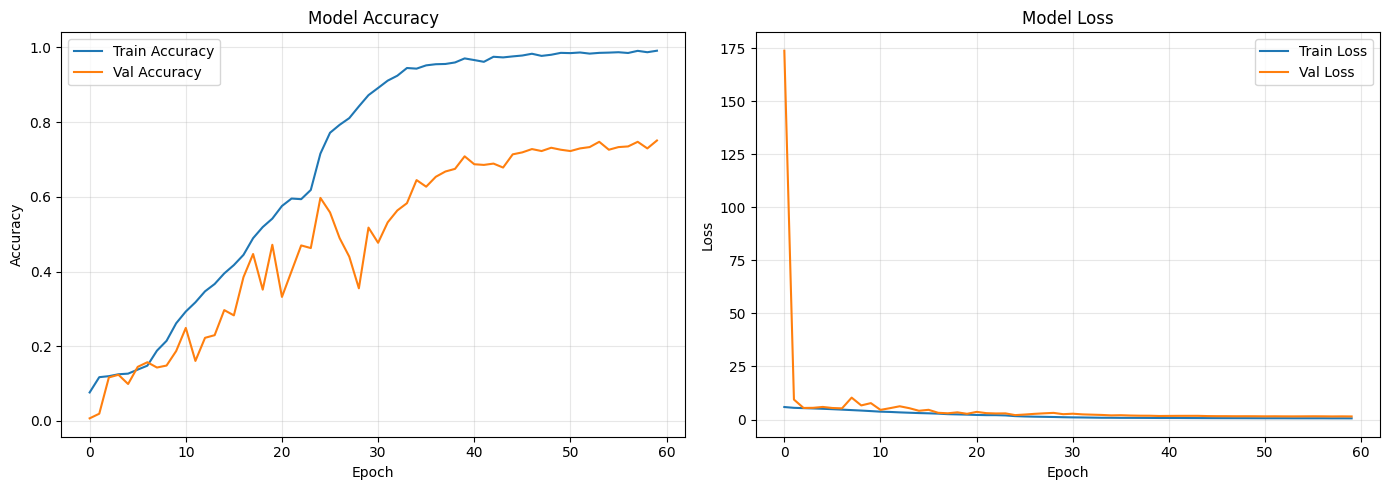

Training curves saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'training_curves.png'), dpi=100)
plt.show()
print("Training curves saved")

## Section 5: Test Set Evaluation

In [10]:
from sklearn.metrics import top_k_accuracy_score

# Load best model
best_model = keras.models.load_model(best_model_path)

# Predict on test set
test_labels_array = np.array(test_labels)
test_preds_probs = best_model.predict(test_ds, verbose=0)
test_preds = np.argmax(test_preds_probs, axis=1)

# Metrics
from sklearn.metrics import accuracy_score, classification_report
top1_acc = accuracy_score(test_labels_array, test_preds)
top5_acc = top_k_accuracy_score(test_labels_array, test_preds_probs, k=5)

print(f"\nTest Set Results:")
print(f"Top-1 Accuracy: {top1_acc:.4f}")
print(f"Top-5 Accuracy: {top5_acc:.4f}")
print(f"\nClassification Report (top classes):")
print(classification_report(test_labels_array, test_preds, zero_division=0))


Test Set Results:
Top-1 Accuracy: 0.6871
Top-5 Accuracy: 0.8611

Classification Report (top classes):
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        80
           1       0.94      0.92      0.93        36
           2       0.92      0.96      0.94        23
           3       0.63      0.89      0.74        19
           4       0.81      1.00      0.89        17
           5       0.79      0.85      0.81        13
           6       0.71      0.83      0.77        12
           7       1.00      0.89      0.94         9
           8       0.78      0.78      0.78         9
           9       0.88      0.78      0.82         9
          10       0.57      0.44      0.50         9
          11       0.78      0.78      0.78         9
          12       0.83      0.62      0.71         8
          13       0.47      1.00      0.64         8
          14       0.80      0.50      0.62         8
          15       0.15      0.2

## Section 5b: Sample Predictions

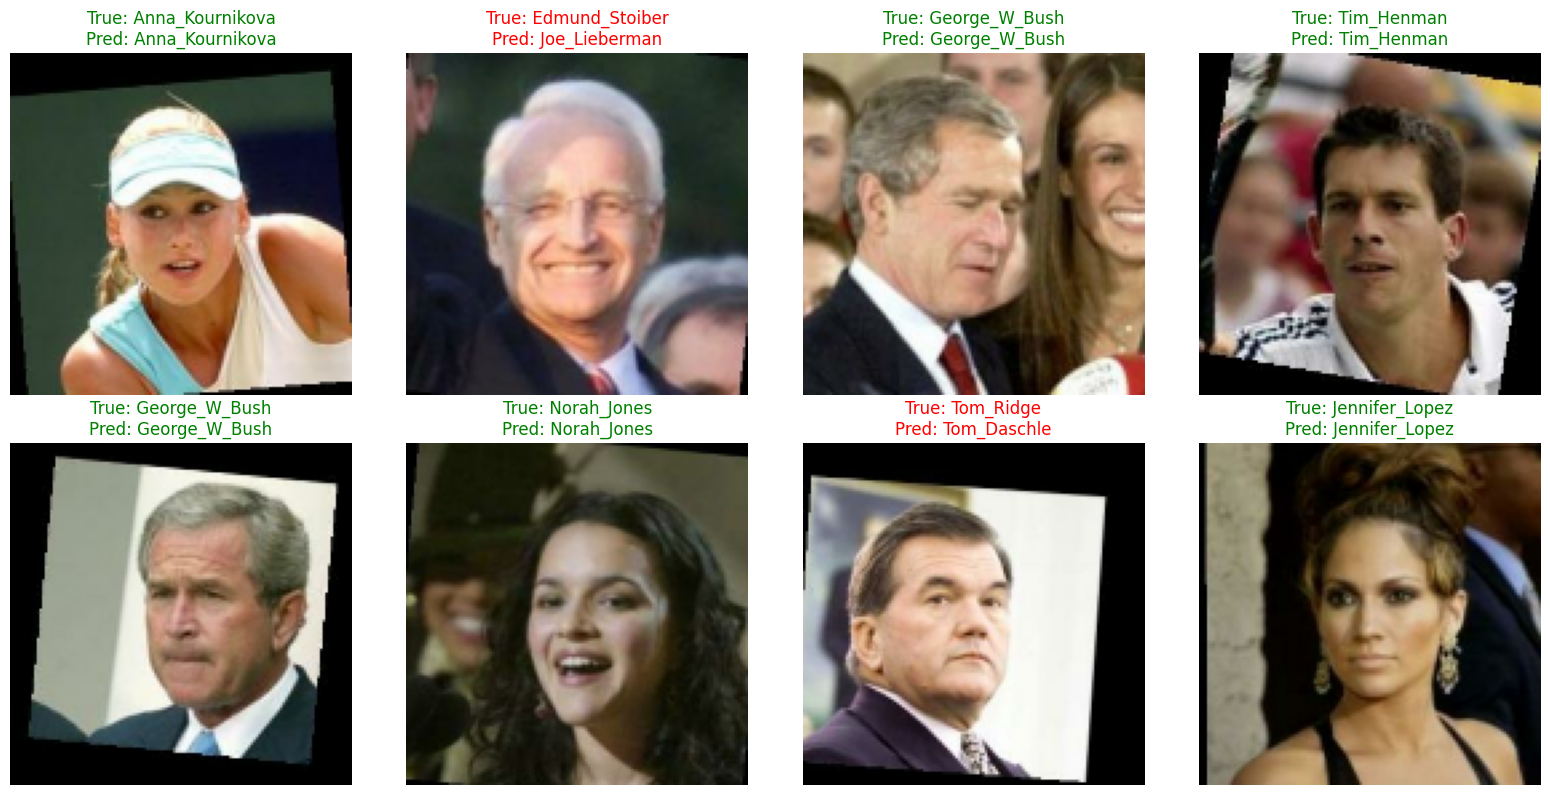

Sample predictions saved


In [11]:
# Show 8 random test samples
sample_indices = np.random.choice(len(test_imgs), 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, sample_idx in enumerate(sample_indices):
    img_path = test_imgs[sample_idx]
    true_label = test_labels[sample_idx]
    pred_label = test_preds[sample_idx]
    
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img_display = img.numpy().astype(np.uint8)
    
    true_name = people[true_label][0]
    pred_name = people[pred_label][0]
    
    axes[idx].imshow(img_display)
    title = f"True: {true_name}\nPred: {pred_name}"
    if true_label == pred_label:
        axes[idx].set_title(title, color='green')
    else:
        axes[idx].set_title(title, color='red')
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'sample_predictions.png'), dpi=100)
plt.show()
print("Sample predictions saved")

## Section 6: Inference Latency

In [12]:
# Single image inference
single_img, _ = next(iter(test_ds.take(1)))
single_img = single_img[0:1]  # Take first image

# Warmup
_ = best_model.predict(single_img, verbose=0)

# Single image timing
start = time.time()
for _ in range(100):
    _ = best_model.predict(single_img, verbose=0)
single_time = (time.time() - start) / 100 * 1000  # ms

# Batch inference
batch_img = next(iter(test_ds.take(1)))[0]  # Full batch
start = time.time()
for _ in range(10):
    _ = best_model.predict(batch_img, verbose=0)
batch_time = (time.time() - start) / 10 * 1000  # ms

print(f"\nInference Latency:")
print(f"Single image: {single_time:.2f} ms")
print(f"Batch ({BATCH_SIZE} images): {batch_time:.2f} ms")
print(f"Per-image (batch): {batch_time/BATCH_SIZE:.2f} ms")


Inference Latency:
Single image: 78.99 ms
Batch (64 images): 825.16 ms
Per-image (batch): 12.89 ms


## Section 7: Save Everything

In [13]:
# Prepare metrics dictionary
metrics = {
    'model_name': 'VGG_Classifier_Improved',
    'num_classes': NUM_CLASSES,
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'epochs_trained': len(history.history['loss']),
    'training_time_seconds': train_time,
    'model_params': {
        'trainable': int(trainable),
        'non_trainable': int(non_trainable),
        'total': int(total),
        'size_mb': float(size_mb)
    },
    'dataset_sizes': {
        'train': len(train_imgs),
        'val': len(val_imgs),
        'test': len(test_imgs)
    },
    'test_metrics': {
        'top1_accuracy': float(top1_acc),
        'top5_accuracy': float(top5_acc)
    },
    'inference_latency': {
        'single_image_ms': float(single_time),
        'batch_ms': float(batch_time),
        'per_image_batch_ms': float(batch_time/BATCH_SIZE)
    },
    'best_epoch_val_accuracy': float(max(history.history['val_accuracy']))
}

metrics_path = os.path.join(OUT_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to {metrics_path}")

# Save model
best_model.save(os.path.join(OUT_DIR, 'vgg_classifier_final.keras'))
print(f"Model saved to {os.path.join(OUT_DIR, 'vgg_classifier_final.keras')}")

Metrics saved to /kaggle/working/vgg_classifier/metrics.json
Model saved to /kaggle/working/vgg_classifier/vgg_classifier_final.keras


## Section 8: Final Summary

In [14]:
print("\n" + "="*70)
print("VGG-BASED FACE RECOGNITION - FINAL SUMMARY")
print("="*70)
print(f"\nDataset:")
print(f"  Identities: {NUM_CLASSES}")
print(f"  Training samples: {len(train_imgs)}")
print(f"  Validation samples: {len(val_imgs)}")
print(f"  Test samples: {len(test_imgs)}")
print(f"\nModel Architecture:")
print(f"  Name: VGG_Classifier (Improved)")
print(f"  Trainable parameters: {trainable:,}")
print(f"  Model size: {size_mb:.2f} MB")
print(f"\nTraining:")
print(f"  Epochs: {len(history.history['loss'])}")
print(f"  Training time: {train_time:.2f} seconds")
print(f"  Best validation accuracy: {max(history.history['val_accuracy']):.4f}")
print(f"  Final training loss: {history.history['loss'][-1]:.4f}")
print(f"\nTest Performance:")
print(f"  Top-1 Accuracy: {top1_acc:.4f}")
print(f"  Top-5 Accuracy: {top5_acc:.4f}")
print(f"\nInference Speed:")
print(f"  Single image: {single_time:.2f} ms")
print(f"  Batch inference: {batch_time/BATCH_SIZE:.2f} ms per image")
print(f"\nOutput Directory: {OUT_DIR}")
print("="*70)


VGG-BASED FACE RECOGNITION - FINAL SUMMARY

Dataset:
  Identities: 158
  Training samples: 2959
  Validation samples: 566
  Test samples: 799

Model Architecture:
  Name: VGG_Classifier (Improved)
  Trainable parameters: 15,159,262
  Model size: 57.87 MB

Training:
  Epochs: 60
  Training time: 1261.91 seconds
  Best validation accuracy: 0.7509
  Final training loss: 0.5596

Test Performance:
  Top-1 Accuracy: 0.6871
  Top-5 Accuracy: 0.8611

Inference Speed:
  Single image: 78.99 ms
  Batch inference: 12.89 ms per image

Output Directory: /kaggle/working/vgg_classifier


In [15]:
# Save class names for demo
import json
class_names = [p[0] for p in people]
with open(os.path.join(OUT_DIR, 'class_names.json'), 'w') as f:
    json.dump(class_names, f, indent=2)
print(f'Saved {len(class_names)} class names to {OUT_DIR}')

Saved 158 class names to /kaggle/working/vgg_classifier
